# Data visualization with Matplotlib and Seaborn


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Notebooks don't have __file__; use a path relative to the notebook's cwd
# (Jupyter sets cwd to the directory containing the .ipynb by default).
NOTEBOOK_DIR = Path.cwd()

# Define the data path: labs/ITSE-1003/data/lab4_data.csv
DATA_PATH = NOTEBOOK_DIR / "data" / "lab4_data.csv"

# Define the output directory: labs/ITSE-1003/matplotlib/generated
OUTPUT_DIR = NOTEBOOK_DIR / "data" / "generated"

# Create the output directory if it does not exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path exists:", DATA_PATH.exists(), "->", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Data path exists: True -> /home/florentino/MyLabs/labs/ITSE-1003/data/lab4_data.csv
Output dir: /home/florentino/MyLabs/labs/ITSE-1003/data/generated


# ----------------------------------------------------------------------------

# Part 1: Data Setup

# Porpose: Load the data and inspect it.


In [3]:
# Read the CSV file into a pandas DataFrame. 
df = pd.read_csv(DATA_PATH)

# Preview the first 5 rows to sanity-check the import.
print("First 5 rows of the dataset:")
print(df.head())

# List the column names so we know exactly which fields are available.
print("\nColumn names:", list(df.columns))

# Show inferred data types for each column.
print("\nData types:\n", df.dtypes)


First 5 rows of the dataset:
   Day  Sales  Profit  Expenses Category
0    1    100      20        80        A
1    2    120      25        95        B
2    3    130      30       100        A
3    4     90      15        75        C
4    5    150      40       110        B

Column names: ['Day', 'Sales', 'Profit', 'Expenses', 'Category']

Data types:
 Day         int64
Sales       int64
Profit      int64
Expenses    int64
Category      str
dtype: object


# ----------------------------------------------------------------------------

# Part 2: Line Chart (Sales vs Day)

# Porpose: Show the trend of sales over time.

# ----------------------------------------------------------------------------


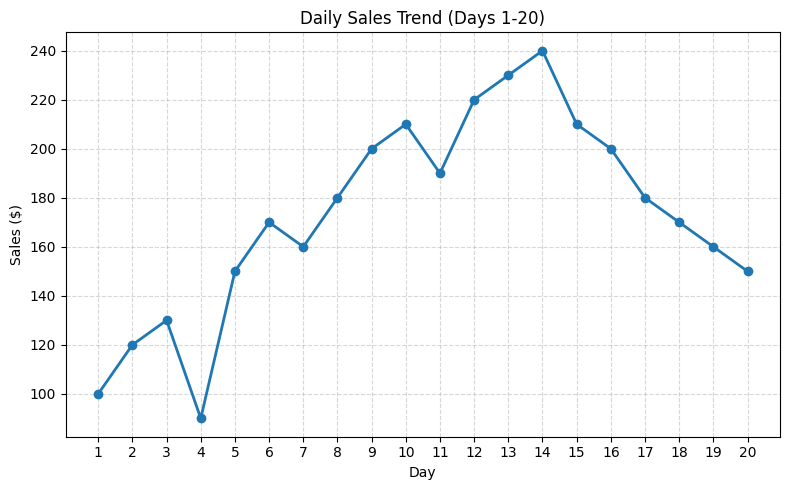

In [4]:
# Create a figure with a specific size.
plt.figure(figsize=(8, 5))

# Plot the sales data for days 1-20.
plt.plot(
    df["Day"], 
    df["Sales"], 
    marker="o", 
    color="#1f77b4", 
    linewidth=2
)

# Add a title and axis labels.
plt.title("Daily Sales Trend (Days 1-20)")
plt.xlabel("Day")
plt.ylabel("Sales ($)")

# Show every day so x-axis labels do not overlap.
plt.xticks(df["Day"])

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 3: Bar Chart (Profit vs Day)

# Porpose: Show the profit trend over time. Makes per-day comparisons.

# ----------------------------------------------------------------------------


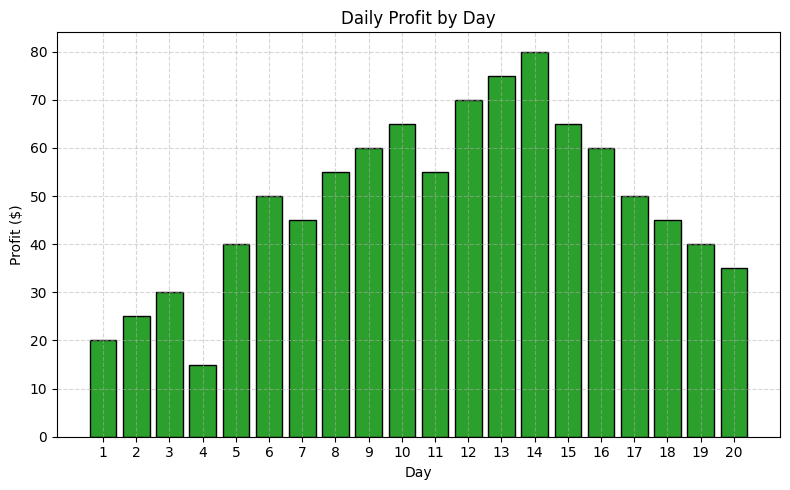

In [6]:

# Create a figure with a specific size.
plt.figure(figsize=(8, 5))

# Plot the profit data for days 1-20.
plt.bar(
    df["Day"], 
    df["Profit"], 
    color="#2ca02c", 
    edgecolor="black"
)

# Add a title and axis labels.
plt.title("Daily Profit by Day")
plt.xlabel("Day")
plt.ylabel("Profit ($)")

# Show every day so x-axis labels do not overlap.
plt.xticks(df["Day"])

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 4: Histogram (Sales distribution)

# Porpose: Show the distribution of sales.

# Observation: `bins` group Sales into ranges; bar height = how many days fall

# in each range, answering "how often does each Sales range occur?".

# ----------------------------------------------------------------------------


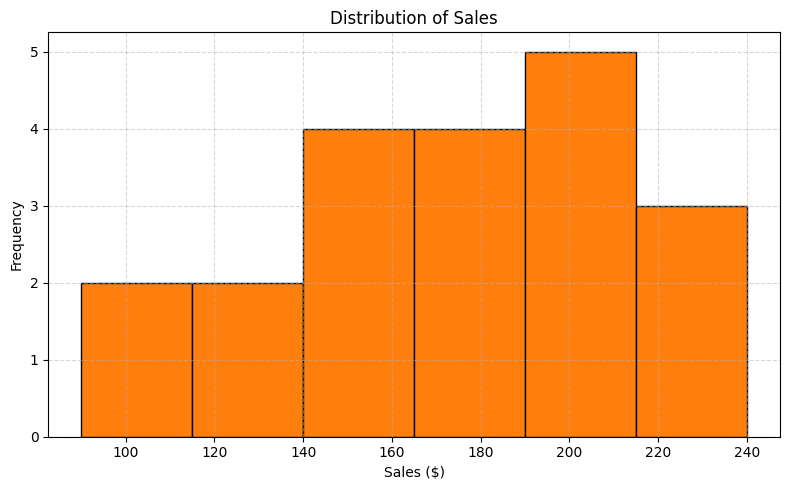

In [7]:

# Create a figure with a specific size.
plt.figure(figsize=(8, 5))

# Plot the sales data for days 1-20.
plt.hist(
    df["Sales"], 
    bins=6, 
    color="#ff7f0e", 
    edgecolor="black"
)

# Add a title and axis labels.
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 5: Scatter Plot (Expenses vs Profit)

# Porpose: Show the relationship between expenses and profit.

# Observation: Profit grows almost linearly with Expenses, indicating a strong

# positive correlation (higher operating costs come with higher profits).

# ----------------------------------------------------------------------------


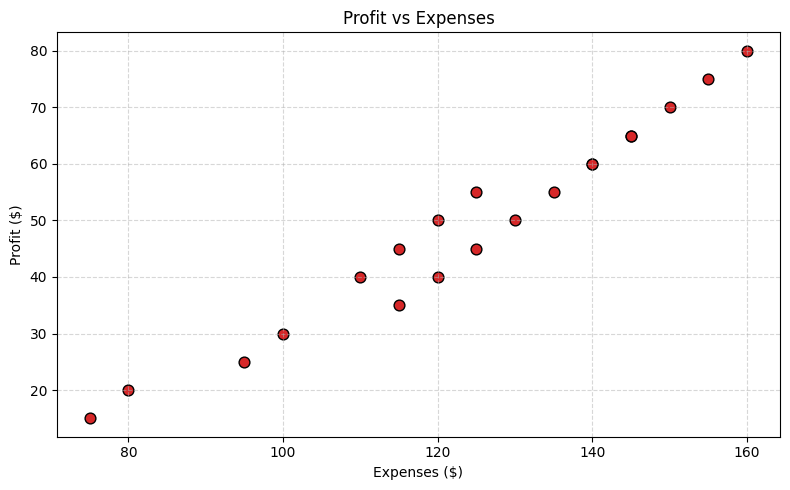

In [8]:
# Create a figure with a specific size.
plt.figure(figsize=(8, 5))

# Plot the expenses vs profit data for days 1-20.
plt.scatter(
    df["Expenses"], 
    df["Profit"], 
    color="#d62728", 
    s=60, 
    edgecolor="black"
)

# Add a title and axis labels.
plt.title("Profit vs Expenses")
plt.xlabel("Expenses ($)")
plt.ylabel("Profit ($)")

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 6: Pie Chart (Category distribution)

# Porpose: Show the distribution of categories.

# Observation: Pie charts show proportions of a whole; each slice's angle is

# the category's share, ideal for "what fraction does each category represent?".

# ----------------------------------------------------------------------------


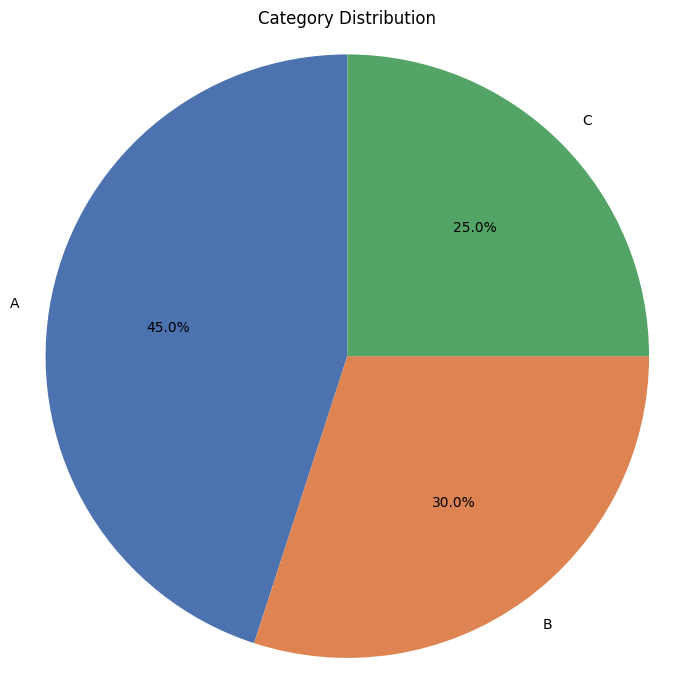

In [14]:

# Count the number of days in each category.
category_counts = df["Category"].value_counts()

# Convert to numpy / list so type checkers see ArrayLike and Sequence[str].
category_values = category_counts.to_numpy()

# Convert the category labels to a list.
category_labels = category_counts.index.tolist()

# Create a figure with a specific size.
plt.figure(figsize=(7, 7))

# Define the colors for the categories (one per slice: A, B, C).
pie_colors = ["#4c72b0", "#dd8452", "#55a467"]

# Plot the category distribution.
plt.pie(
    category_values,
    labels=category_labels,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
)

# Add a title and axis labels.
plt.title("Category Distribution")
#plt.xlabel("Category")
#plt.ylabel("Frequency")

# Add a grid.
#plt.grid(True, linestyle="--", alpha=0.5)

# Keep the pie circular.
plt.axis("equal")

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 7: Box Plot (Sales, Profit, Expenses)

# Porpose: Show the spread of sales, profit and expenses.

# Observation: Box = Q1-Q3 (middle 50%), line inside = median; whiskers cover

# the rest of the range and any points beyond them are potential outliers.

# Note: matplotlib 3.9+ uses `tick_labels=` instead of the deprecated `labels=`.

# ----------------------------------------------------------------------------


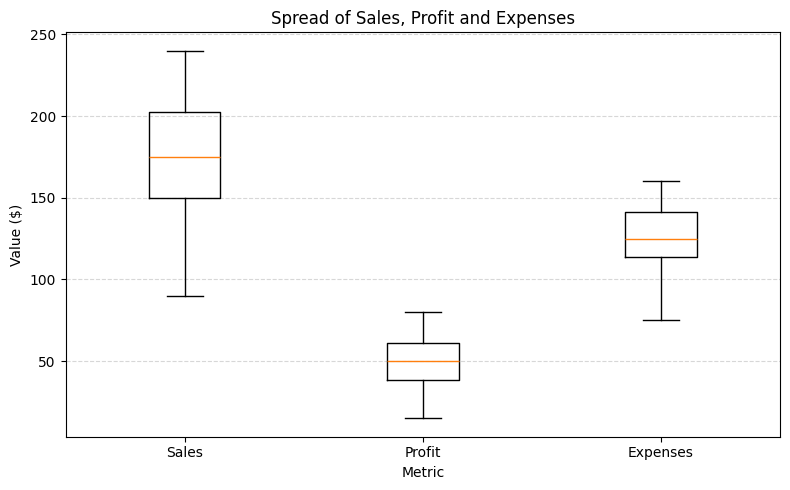

In [10]:
# Create a figure with a specific size.
plt.figure(figsize=(8, 5))

# Plot the sales, profit and expenses data for days 1-20.
plt.boxplot(
    [df["Sales"], df["Profit"], df["Expenses"]],
    tick_labels=["Sales", "Profit", "Expenses"],
)

# Add a title and axis labels.
plt.title("Spread of Sales, Profit and Expenses")
plt.xlabel("Metric")
plt.ylabel("Value ($)")

# Add a grid.
plt.grid(True, axis="y", linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()


# ----------------------------------------------------------------------------

# Part 8: Heatmap (Seaborn)

# Porpose: Show the correlation between the numeric columns.

# ----------------------------------------------------------------------------


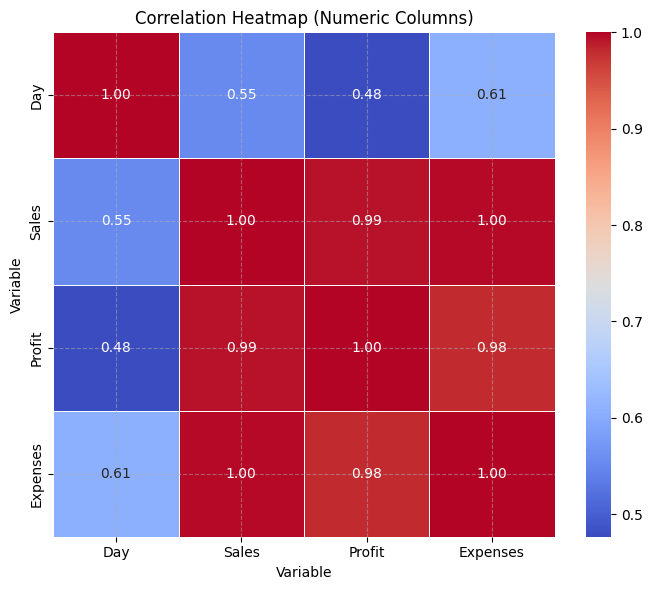

In [11]:
# Drop "Category" (non-numeric) so .corr() can run on the numeric columns.
df_numeric = df.drop(columns=["Category"])

# Compute the correlation between the numeric columns.
corr = df_numeric.corr()

# Create a figure with a specific size.
plt.figure(figsize=(7, 6))

# Plot the correlation heatmap.
sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5
)

# Add a title and axis labels.
plt.title("Correlation Heatmap (Numeric Columns)")
plt.xlabel("Variable")
plt.ylabel("Variable")

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Part 9: Subplots (Line chart + Pie chart in one figure)

# Porpose: Show the sales trend and category distribution in one figure.

# ----------------------------------------------------------------------------


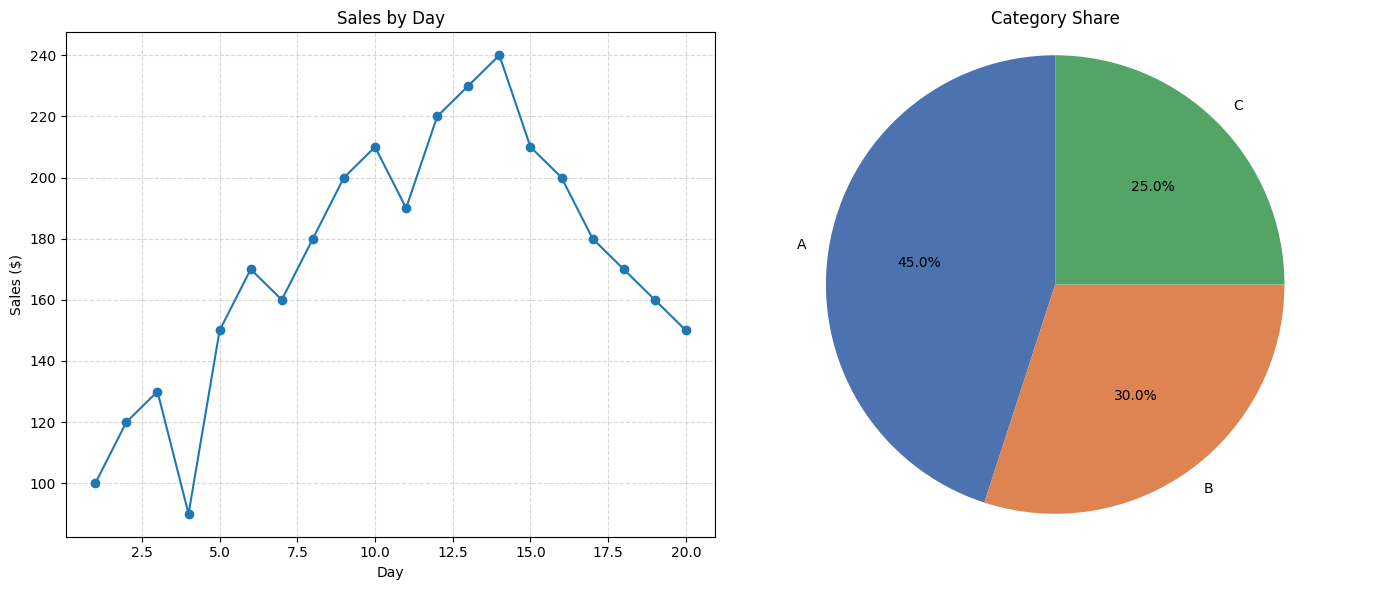

In [12]:
# Create a figure with a specific size.
plt.figure(figsize=(14, 6))

# Left subplot: Sales line chart.
plt.subplot(1, 2, 1)

# Plot the sales data for days 1-20.
plt.plot(df["Day"], df["Sales"], marker="o", color="#1f77b4")

# Add a title and axis labels.
plt.title("Sales by Day")
plt.xlabel("Day")
plt.ylabel("Sales ($)")

# Add a grid.
plt.grid(True, linestyle="--", alpha=0.5)

# Right subplot: Category pie chart (reuse the typed values/labels from Part 6).
plt.subplot(1, 2, 2)

# Plot the category distribution (reuse pie_colors from Part 6).
plt.pie(
    category_values,
    labels=category_labels,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
)

# Add a title and axis labels.
plt.title("Category Share")
plt.axis("equal")

# Add a tight layout.
plt.tight_layout()

# ----------------------------------------------------------------------------

# Bonus: customisations (4 of the 5 suggested options)

# Porpose: Show the daily sales with custom colours, rotated x-axis labels, custom x-axis tick interval and grid lines on the y-axis only.

# ----------------------------------------------------------------------------

# Customisations applied below:

# 1. Custom colors for each bar (one per category-coloured bucket).

# 2. Rotated x-axis labels (45 degrees) for readability.

# 3. Custom x-axis tick interval using plt.xticks(range(...)).

# 4. Grid lines on the y-axis only.

# 5. Saved the chart to PNG with dpi=300.



Bonus chart saved to: /home/florentino/MyLabs/labs/ITSE-1003/data/generated/lab4_bonus_sales.png


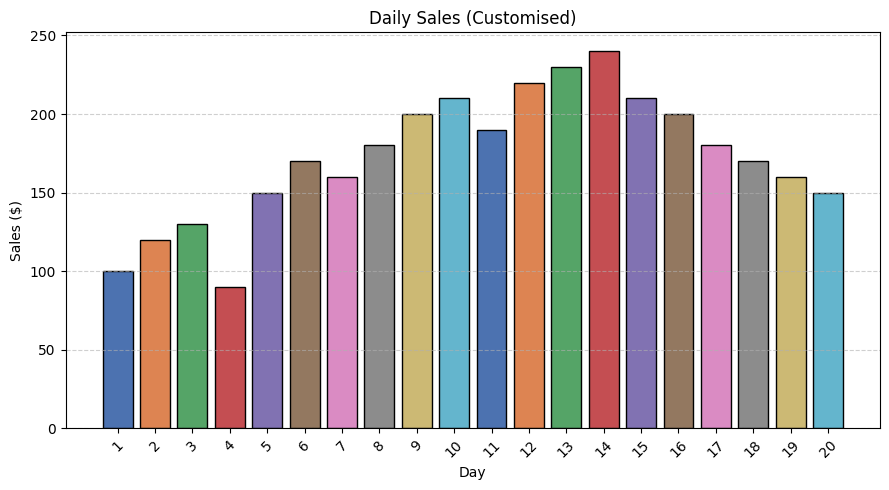

In [13]:
# Create a figure with a specific size.
plt.figure(figsize=(9, 5))

# Plot the daily sales data with custom colours.
bar_colors = ["#4c72b0", "#dd8452", "#55a467", "#c44e52", "#8172b2",
              "#937860", "#da8bc3", "#8c8c8c", "#ccb974", "#64b5cd"] * 2

# Plot the daily sales data with custom colours.
plt.bar(df["Day"], df["Sales"], color=bar_colors, edgecolor="black")

# Add a title and axis labels.
plt.title("Daily Sales (Customised)")
plt.xlabel("Day")
plt.ylabel("Sales ($)")

# Rotate the x-axis labels.
plt.xticks(range(1, 21, 1), rotation=45)

# Add a grid.
plt.grid(True, axis="y", linestyle="--", alpha=0.6)

# Add a tight layout.
plt.tight_layout()

# Save the chart to PNG with dpi=300.
bonus_path = OUTPUT_DIR / "lab4_bonus_sales.png"

# Print the path to the saved chart.
plt.savefig(bonus_path, dpi=300)
print(f"\nBonus chart saved to: {bonus_path}")

# Display every figure created above.
plt.show()
